In [21]:
import pandas as pd

In [22]:
df = pd.read_csv("arxiv_to_s2_mapping.csv")

In [23]:
len(df[~df["error"].isna()]) / len(df)

0.051036682615629984

In [24]:
df.columns

Index(['arxiv_id_raw', 'arxiv_id_no_version', 'arxiv_title', 'arxiv_published',
       'arxiv_primary_category', 's2_found', 's2_paperId', 's2_title',
       's2_year', 's2_venue', 's2_authors', 's2_referenceCount',
       's2_citationCount', 's2_externalIds_json', 's2_fieldsOfStudy_json',
       's2_s2FieldsOfStudy_json', 's2_publicationDate', 'error'],
      dtype='object')

In [25]:
df.head()

,arxiv_id_raw,arxiv_id_no_version,arxiv_title,arxiv_published,arxiv_primary_category,s2_found,s2_paperId,s2_title,s2_year,s2_venue,s2_authors,s2_referenceCount,s2_citationCount,s2_externalIds_json,s2_fieldsOfStudy_json,s2_s2FieldsOfStudy_json,s2_publicationDate,error
0,2603.13131v1,2603.13131,Steve-Evolving: Open-World Embodied Self-Evolu...,2026-03-13T16:23:34Z,cs.AI,1,8b9d264fab816c9bbcbe6930f81fbabf18bdf9c7,Steve-Evolving: Open-World Embodied Self-Evolu...,2026.0,NaN,Zhen Xie; Zhisheng Chen; Ziyan Weng; Tingyu Wu...,36.0,0.0,"{""ArXiv"": ""2603.13131"", ""CorpusId"": 286519800}","[""Computer Science""]","[{""category"": ""Computer Science"", ""source"": ""e...",2026-03-13,NaN
1,2603.12659v1,2603.12659,AVION: Aerial Vision-Language Instruction from...,2026-03-13T05:02:01Z,cs.CV,1,6c23fd6331fd3900ecd027149016cdebdf5d16e5,AVION: Aerial Vision-Language Instruction from...,2026.0,NaN,Yu Hu; Jianyang Gu; Hao Liu; Yue Cao; Jozsef H...,40.0,0.0,"{""ArXiv"": ""2603.12659"", ""CorpusId"": 286517933}","[""Computer Science""]","[{""category"": ""Computer Science"", ""source"": ""e...",2026-03-13,NaN
2,2603.12344v1,2603.12344,Generalist Large Language Models for Molecular...,2026-03-12T18:06:21Z,cs.LG,1,52e0a9cc69b002b4ca9fb61c7ba9162baf74f8f2,Generalist Large Language Models for Molecular...,2026.0,NaN,Khiem Le; Sreejata Dey; Marcos Martínez Galind...,47.0,0.0,"{""ArXiv"": ""2603.12344"", ""CorpusId"": 286517587}","[""Computer Science""]","[{""category"": ""Computer Science"", ""source"": ""e...",2026-03-12,NaN
3,2603.12191v1,2603.12191,Long-Context Encoder Models for Polish Languag...,2026-03-12T17:21:45Z,cs.CL,1,f74953e56342a8bdd0a13b5341e2d5a97a98e297,Long-Context Encoder Models for Polish Languag...,2026.0,NaN,Slawomir Dadas; Rafal Po'swiata; Marek Kozłows...,36.0,0.0,"{""ArXiv"": ""2603.12191"", ""CorpusId"": 286493398}","[""Computer Science""]","[{""category"": ""Computer Science"", ""source"": ""e...",2026-03-12,NaN
4,2603.11917v1,2603.11917,PicoSAM3: Real-Time In-Sensor Region-of-Intere...,2026-03-12T13:31:43Z,cs.CV,1,cafb176e6aeae2c9c0aeca84c559fbd07eefd29d,PicoSAM3: Real-Time In-Sensor Region-of-Intere...,2026.0,NaN,Pietro Bonazzi; Nicola Farronato; Stefan Zihlm...,55.0,0.0,"{""ArXiv"": ""2603.11917"", ""CorpusId"": 286493169}","[""Computer Science""]","[{""category"": ""Computer Science"", ""source"": ""e...",2026-03-12,NaN


In [26]:
len(df[~df["s2_venue"].isna()]) / len(df) # Venue non-NaN proportion

0.8038277511961722

In [27]:
df["s2_referenceCount"] # how many other papers were referenced

0      36.0
1      40.0
2      47.0
3      36.0
4      55.0
       ... 
622    28.0
623    68.0
624     0.0
625    96.0
626    14.0
Name: s2_referenceCount, Length: 627, dtype: float64

In [28]:
df["s2_citationCount"] # how many citationd did it get

0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
622    3.0
623    1.0
624    4.0
625    0.0
626    0.0
Name: s2_citationCount, Length: 627, dtype: float64

turn df["s2_publicationDate"] into date format, and make two histograms, one with s2_referenceCount as y, the other with s2_citationCount as y, plot over quarter bins. 

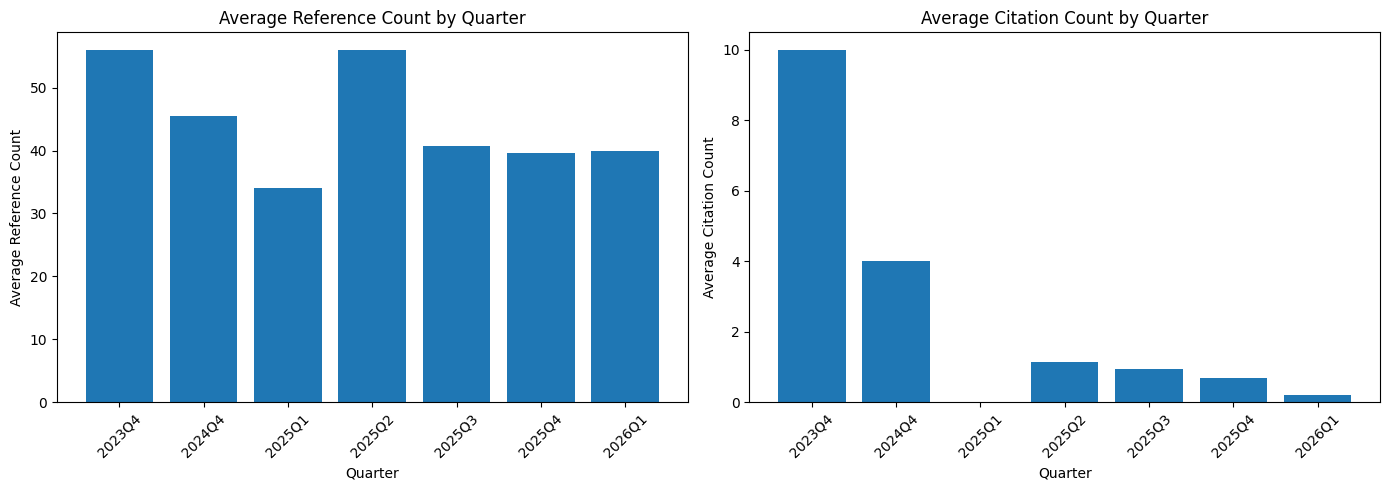

In [29]:
import matplotlib.pyplot as plt

# Convert s2_publicationDate to datetime
df['s2_publicationDate'] = pd.to_datetime(df['s2_publicationDate'])

# Extract quarter from publication date
df['quarter'] = df['s2_publicationDate'].dt.to_period('Q')

# Group by quarter and aggregate
quarterly_data = df.groupby('quarter')[['s2_referenceCount', 's2_citationCount']].mean()

# Create two histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for reference count
axes[0].bar(range(len(quarterly_data)), quarterly_data['s2_referenceCount'])
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Average Reference Count')
axes[0].set_title('Average Reference Count by Quarter')
axes[0].set_xticks(range(len(quarterly_data)))
axes[0].set_xticklabels(quarterly_data.index.astype(str), rotation=45)

# Histogram for citation count
axes[1].bar(range(len(quarterly_data)), quarterly_data['s2_citationCount'])
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Average Citation Count')
axes[1].set_title('Average Citation Count by Quarter')
axes[1].set_xticks(range(len(quarterly_data)))
axes[1].set_xticklabels(quarterly_data.index.astype(str), rotation=45)

plt.tight_layout()
plt.show()